In [13]:
import pywt
import pandas as pd
import numpy as np

from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.analysis.dfa import dfa
from StatTools.analysis.utils import analyse_zero_cross_ff
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [23]:
frame_num=16384
np.random.seed(seed=42)
levels = 5 # num of cA
hurst_list = [round(0.2*i, 2) for i in range(1, 10)]
results = []
for hurst in hurst_list:
    field = ndfnoise(shape=(frame_num,), hurst=hurst, normalize=True)
    
    wavelet_transform = []
    wavelet_transform.append(field)
    for level in range(levels):
        cA, _ = pywt.wavedec(wavelet_transform[-1], 'db2', level=1)
        wavelet_transform.append(cA)

    ff_params = []
    for idx, level in enumerate(wavelet_transform):
        s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(4), np.log(len(level)/5), 0.5)])
        _, F2_s = dfa(level, s_values=s_values)
        F_s = np.sqrt(F2_s)
        ff_param, _ = analyse_zero_cross_ff(F_s.reshape(1, -1), s_values.reshape(1, -1))
        ff_params.append(ff_param.slopes[0].value)

        results.append({
                'Target_H': hurst,
                'Level': idx,
                'H_est': ff_param.slopes[0].value
            })

    
df_results = pd.DataFrame(results)

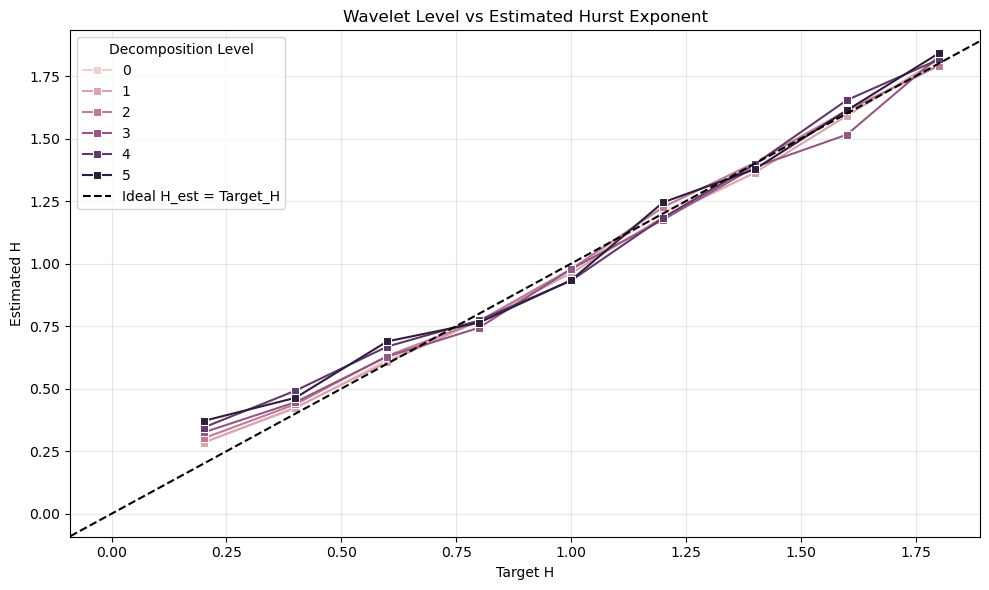

In [24]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x='Target_H', y='H_est', hue='Level', marker='s')
plt.axline((0, 0), slope=1, color='black', linestyle='--', label='Ideal H_est = Target_H')
plt.title('Wavelet Level vs Estimated Hurst Exponent')
plt.xlabel('Target H')
plt.ylabel('Estimated H')
plt.legend(title='Decomposition Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# nrows=np.ceil(len(wavelet_transform)).astype(np.int16)

# fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(10, nrows*3))
# axes = np.atleast_2d(axes).flatten()
# for idx,(ax, level) in enumerate(zip(axes, wavelet_transform)):
#     ax.plot(level, label=f'H: {ff_params[idx]:.3f}')
#     ax.legend()
# plt.show()

Starting 2D Experiment...


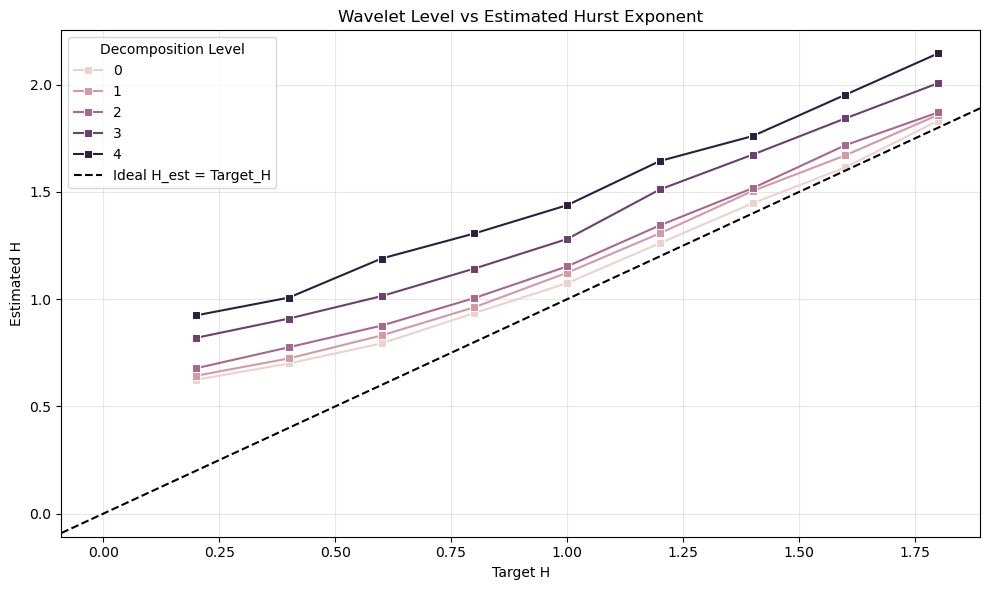

In [25]:
size_2d = 1024  
levels_2d = 4  
wavelet_name = 'db1'

results_2d = []

print("Starting 2D Experiment...")
for hurst in hurst_list:
    
    field_2d = ndfnoise(shape=(size_2d, size_2d), hurst=hurst, normalize=True)
    
    
    wavelet_transform_2d = [field_2d]
    current_field = field_2d
    
    for _ in range(levels_2d):
        
        coeffs = pywt.wavedec2(current_field, wavelet_name, level=1)
        cA = coeffs[0] 
        wavelet_transform_2d.append(cA)
        current_field = cA

    
    for idx, level_field in enumerate(wavelet_transform_2d):
        h_est_sum = 0
        count = 0
        
        n_rows, n_cols = level_field.shape
        
        
        num_samples = min(100, n_rows) 
        row_indices = np.random.choice(n_rows, num_samples, replace=False)
        
        h_estimates = []
        
        for r in row_indices:
            signal_1d = level_field[r, :]
            s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(4), np.log(len(signal_1d)/5), 0.5)])
            if len(s_values) < 3: continue
            
            _, F2_s = dfa(signal_1d, s_values=s_values)
            F_s = np.sqrt(F2_s)
            ff_param, _ = analyse_zero_cross_ff(F_s.reshape(1, -1), s_values.reshape(1, -1))
            h_estimates.append(ff_param.slopes[0].value)
            
        
        if h_estimates:
            mean_h = np.mean(h_estimates)
            results_2d.append({
                'Target_H': hurst,
                'Level': idx,
                'H_est_2D': mean_h
            })

df_results_2d = pd.DataFrame(results_2d)

# --- Визуализация результатов 2D ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results_2d, x='Target_H', y='H_est_2D', hue='Level', marker='s')
plt.axline((0, 0), slope=1, color='black', linestyle='--', label='Ideal H_est = Target_H')
plt.title('Wavelet Level vs Estimated Hurst Exponent')
plt.xlabel('Target H')
plt.ylabel('Estimated H')
plt.legend(title='Decomposition Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
